In [1]:
print("""This script was written in support of the experiments carried out in:
Nic Ezzell and Itay Hen, Advanced measurement techniques in quantum Monte Carlo: The permutation matrix representation approach, arXiv:2504.07295 (2025).""")

This script was written in support of the experiments carried out in:
Nic Ezzell and Itay Hen, Advanced measurement techniques in quantum Monte Carlo: The permutation matrix representation approach, arXiv:2504.07295 (2025).


In [2]:
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import glob
import pandas as pd
import sys
import scipy
sys.path.append("../../utils")

matplotlib.style.use("./style.mplstyle")
new_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
              '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
              '#bcbd22', '#17becf']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r"\usepackage{amsmath}\usepackage{amsfonts}")

In [3]:
fname = "../data/summary_for_just_2q_random_obs_experiment.csv"
df_2q = pd.read_csv(fname)
fname = "../data/summary_for_rotated_n100_random_obs_experiment.csv"
df_rot = pd.read_csv(fname)

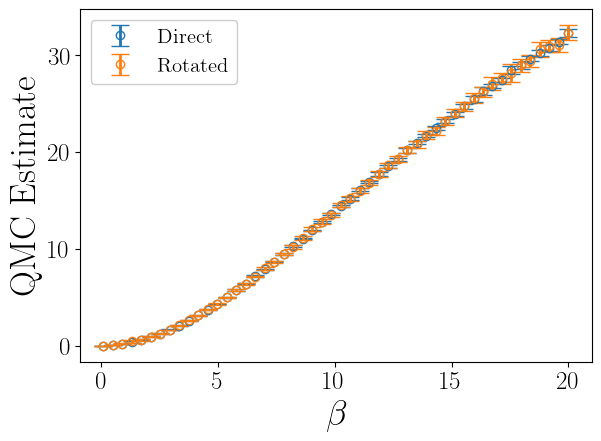

In [40]:
ebar_size = 6.5
height = 5
width = height * 1.618
k = 0
labels = ["Direct", "Rotated"]
obs_list = ["A", "A2", "A_tau_A", "A_Eint", "A_Fint"]
obs = obs_list[4]
for df in [df_2q, df_rot]:
    x = df["beta"]
    y = df[f"total_mean_{obs}"]
    yerr = 3 * df[f"total_std_{obs}"]
    color = f"C{k}"
    plt.errorbar(x=x, y=y, yerr=yerr, fmt='o', capsize=ebar_size, 
                 markerfacecolor='none', markeredgecolor=color, ecolor=color, label=labels[k])
    k +=1 
    
# Set labels with larger fonts
plt.xlabel(r"$\beta$", fontsize=26)
plt.ylabel("QMC Estimate", fontsize=26)
#plt.legend(fontsize=18, loc=(0.01,0.37))
plt.legend(fontsize=15)

# Adjust tick parameters
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# Optimize layout for readability
plt.tight_layout(pad=1)
plt.savefig("advmeas_figures/test_random_model_A_Fint.pdf", dpi=800, bbox_inches="tight")

In [12]:
# Identify columns like elapsed_time_rank0 ... rank5
rank_cols = [c for c in df_2q.columns if c.startswith("elapsed_time_rank")]

# Melt into long form
df_long_2q = df_2q.melt(
    id_vars=["beta"],            # keep beta as-is
    value_vars=rank_cols,        # the rank columns
    var_name="rank",             # new column: 'rank'
    value_name="elapsed_time",   # new column: each time
)

# Extract rank number (0,1,...5) as an integer
df_long_2q["rank"] = df_long_2q["rank"].str.extract(r"(\d+)").astype(int)

# Identify columns like elapsed_time_rank0 ... rank5
rank_cols = [c for c in df_rot.columns if c.startswith("elapsed_time_rank")]

# Melt into long form
df_long_rot = df_rot.melt(
    id_vars=["beta"],            # keep beta as-is
    value_vars=rank_cols,        # the rank columns
    var_name="rank",             # new column: 'rank'
    value_name="elapsed_time",   # new column: each time
)

# Extract rank number (0,1,...5) as an integer
df_long_rot["rank"] = df_long_rot["rank"].str.extract(r"(\d+)").astype(int)

/var/folders/2w/_70fq7w11c36fkhz8pnqp8gw0000gp/T/ipykernel_17075/1914845183.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)


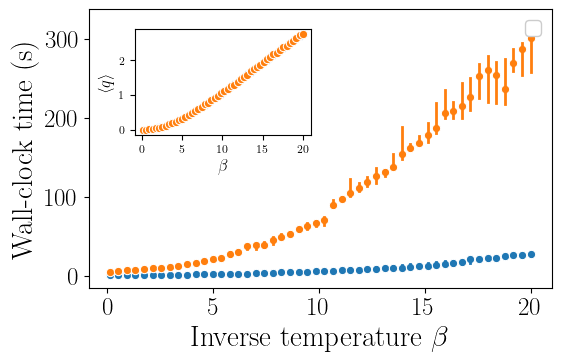

In [34]:
fig, ax = plt.subplots(figsize=(6,4))

k = 0
for df in [df_long_2q, df_long_rot]:
    sns.lineplot(
        data=df,
        x="beta",
        y="elapsed_time",
        estimator="median",      # center = median
        errorbar=("pi", 99.7),     # percentile interval 2.5–97.5
        err_style="bars",        # or "band"
        marker="o",
        linestyle="",
        ax=ax
    )
    k += 1

ax.set_xlabel(r"Inverse temperature $\beta$")
ax.set_ylabel("Wall-clock time (s)")
ax.grid(False)
plt.tight_layout()

# === Inset axes ===
# width="40%", height="40%", location upper right inside the parent axes
# Define inset width & height in *axes fraction*
inset_ax = ax.inset_axes([0.1, 0.55, 0.38, 0.38])  # right/bottom area, avoids label clashes

k = 0
labels = ["2q", "rot"]
for df in [df_2q, df_rot]:
    x = df["beta"]
    y = df["total_mean_q"]
    color = f"C{k}"
    sns.lineplot(
        data=df,
        x='beta',
        y=df["total_mean_q"],
        markersize=6,
        legend=False,
        marker='o',
        linestyle='',
        ax=inset_ax,
    )
    k +=1 
    
# Set labels with larger fonts
# Labels and ticks smaller
inset_ax.set_xlabel(r"$\beta$", fontsize=12)
inset_ax.set_ylabel(r"$\langle q \rangle$", fontsize=12)
inset_ax.tick_params(labelsize=8)
#plt.legend(fontsize=18, loc=(0.01,0.37))
plt.legend(fontsize=15)

# Adjust tick parameters
plt.tick_params(axis='both', which='major', labelsize=18)
plt.tick_params(axis='both', which='minor', labelsize=18)

# Optimize layout for readability
plt.tight_layout(pad=1) 
plt.savefig("advmeas_figures/timing_random_model.pdf", dpi=800, bbox_inches="tight")

In [51]:
x = df_2q["beta"]
y = df_2q["wall_clock_time"]

In [53]:
import numpy as np

x = df_2q["beta"]
y = df_2q["wall_clock_time"]

# x, y are numpy arrays
logx = np.log(x)
logy = np.log(y)

# linear fit in log–log space:  log y = log a + b log x
b, loga = np.polyfit(logx, logy, 1)

a = np.exp(loga)

print("a =", a)
print("b =", b)

a = 0.7197960664727671
b = 0.9971918704054954


In [54]:
x = df_rot["beta"]
y = df_rot["wall_clock_time"]

# x, y are numpy arrays
logx = np.log(x)
logy = np.log(y)

# linear fit in log–log space:  log y = log a + b log x
b, loga = np.polyfit(logx, logy, 1)

a = np.exp(loga)

print("a =", a)
print("b =", b)

a = 6.833249535872242
b = 1.1090649867264235
